In [1]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            roc_auc_score, confusion_matrix, classification_report, 
                            ConfusionMatrixDisplay, RocCurveDisplay,)    
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns                              
sns.set_theme(style='whitegrid', palette='pastel') 

os.makedirs('../outputs/models', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

X = pd.read_csv('../data/processed/X.csv')
y = pd.read_csv('../data/processed/y.csv').squeeze()

In [2]:
# Data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y,)
print('Train: ', X_train.shape, y_train.shape)
print('Test: ', X_test.shape, y_test.shape)
print('Train Churn Rate: ', y_train.mean().round(3))
print('Test Churn Rate: ', y_test.mean().round(3))

Train:  (8000, 18) (8000,)
Test:  (2000, 18) (2000,)
Train Churn Rate:  0.204
Test Churn Rate:  0.204


In [3]:
# Scale flow
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 
                 'BalancePerProduct', 'BalanceSalaryRatio', 'TenureAgeRatio',]
scaler = StandardScaler()
scaler.fit(X_train[cols_to_scale])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Save the fitted scaler (later use)
joblib.dump(scaler, '../outputs/models/scaler.joblib')

# Verify scaling worked or not
print('Train: ')
print(X_train_scaled[cols_to_scale].agg(['mean', 'std']).round(3))
print('\nTest: ')
print(X_test_scaled[cols_to_scale].agg(['mean', 'std']).round(3))

Train: 
      CreditScore  Age  Tenure  Balance  EstimatedSalary  BalancePerProduct  \
mean         -0.0  0.0    -0.0      0.0             -0.0               -0.0   
std           1.0  1.0     1.0      1.0              1.0                1.0   

      BalanceSalaryRatio  TenureAgeRatio  
mean                 0.0             0.0  
std                  1.0             1.0  

Test: 
      CreditScore    Age  Tenure  Balance  EstimatedSalary  BalancePerProduct  \
mean       -0.012 -0.012  -0.007    0.008            0.031              0.002   
std         1.003  0.982   0.992    1.008            1.015              1.003   

      BalanceSalaryRatio  TenureAgeRatio  
mean              -0.014           0.007  
std                0.126           1.015  


In [4]:
# Prepare for verify stage
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

In [5]:
# Building models

# 1st model - Logistic Regression
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)

print(f'Logistic Regression Train Accuracy: {logreg.score(X_train_scaled, y_train):.3f}')

# 2nd model - Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2, 
                            class_weight='balanced', n_jobs=-1, random_state=42,)
rf.fit(X_train, y_train)

print(f'Random Forest Train Accuracy: {rf.score(X_train, y_train):.3f}')

# 3rd model - XGBoost

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f'scale_pos_weight = {scale_pos:.2f}')

xgb = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
                    scale_pos_weight=scale_pos, eval_metric='logloss', random_state=42, n_jobs=-1,)
xgb.fit(X_train, y_train)

print(f'XGBoost Train Accuracy: {xgb.score(X_train, y_train):.3f}')

models =  {'Logistic Regression': (logreg, X_train_scaled, X_test_scaled),
           'Random Forest': (rf, X_train, X_test),
           'XGBoost': (xgb, X_train, X_test),}

# Sanity check
for name, (model, X_tr, X_te) in models.items():
    train_acc = model.score(X_tr, y_train)
    test_acc = model.score(X_te, y_test)
    print(f'{name:22s} train={train_acc:.3f} test={test_acc:.3f}')
    
           


Logistic Regression Train Accuracy: 0.735
Random Forest Train Accuracy: 0.989
scale_pos_weight = 3.91
XGBoost Train Accuracy: 0.911
Logistic Regression    train=0.735 test=0.728
Random Forest          train=0.989 test=0.866
XGBoost                train=0.911 test=0.820


In [6]:
# Models evaluation
def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {'model': name,
            'accuracy': accuracy_score(y_te, y_pred),
            'precision': precision_score(y_te, y_pred),
            'recall': recall_score(y_te, y_pred),
            'f1': f1_score(y_te, y_pred),
            'roc_auc': roc_auc_score(y_te, y_proba),}

results = pd.DataFrame([evaluate(name, model, X_te, y_test)
                        for name, (model, _, X_te) in models.items()]).set_index('model').round(3)

print(results)

                     accuracy  precision  recall     f1  roc_auc
model                                                           
Logistic Regression     0.728      0.399   0.666  0.499    0.787
Random Forest           0.866      0.735   0.531  0.616    0.857
XGBoost                 0.820      0.545   0.686  0.607    0.854


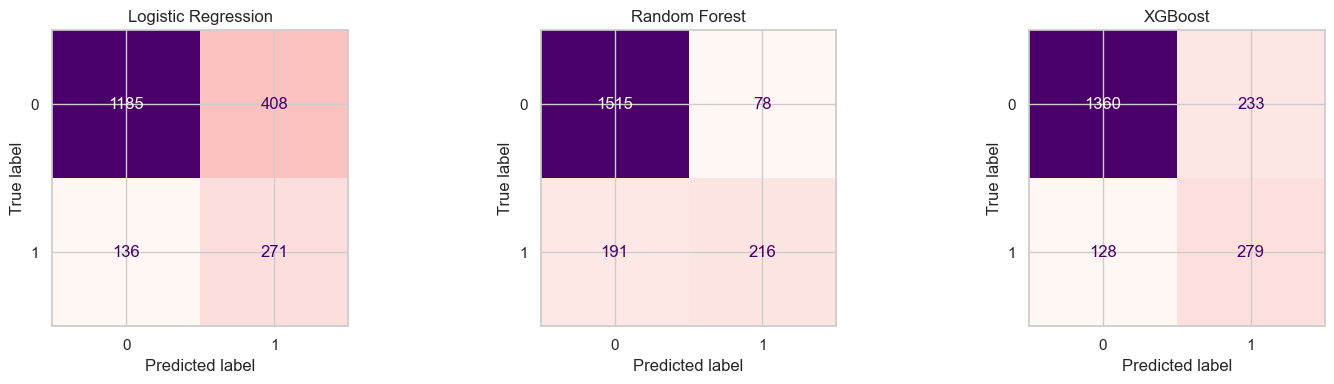

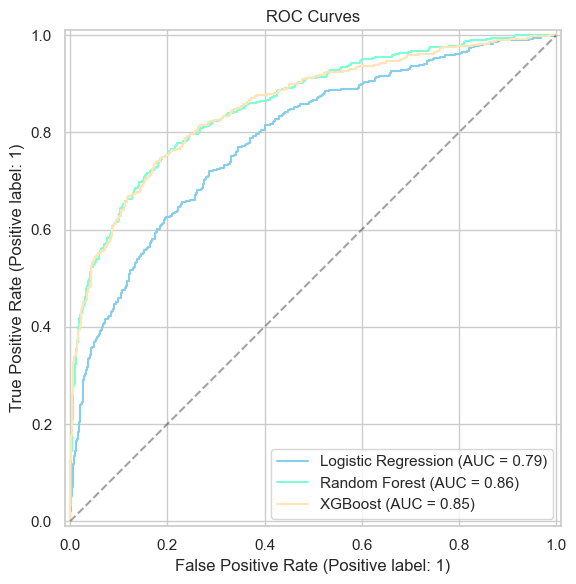

In [7]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (model, _, X_te)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_te, y_test, ax=ax, cmap='RdPu', colorbar=False,)
    ax.set_title(name)
plt.tight_layout()
plt.savefig('../outputs/figures/08_confusion_matrices.png', dpi=120, bbox_inches='tight')             
plt.show()


# ROC curves
plt.figure(figsize=(7, 6))
colors = {'Logistic Regression': 'skyblue',
        'Random Forest': 'aquamarine',
        'XGBoost': 'moccasin'}
for name, (model, _, X_te) in models.items():
    RocCurveDisplay.from_estimator(model, X_te, y_test, name=name, ax=plt.gca(), curve_kwargs={'color': colors[name]})
plt.plot([0,1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.title('ROC Curves')
plt.tight_layout()
plt.savefig('../outputs/figures/09_roc_curves.png',dpi=120, bbox_inches='tight')                     
plt.show() 


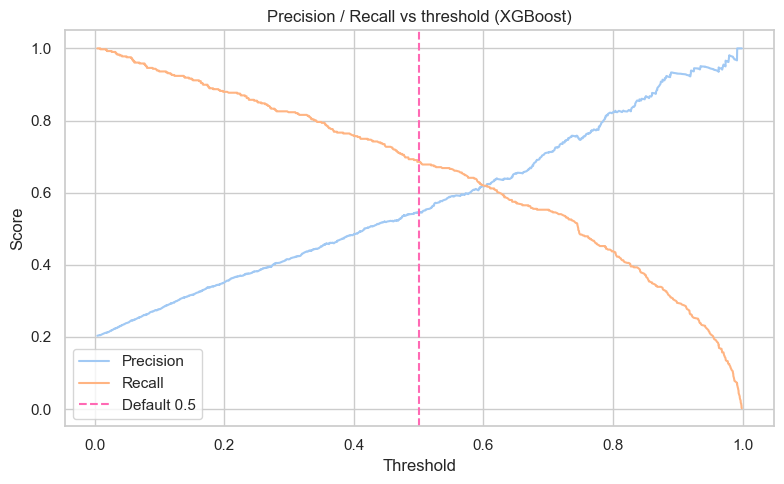

At threshold - XGBoost 0.35
Precision: 0.451
Recall   : 0.794
F1       : 0.575


In [8]:
# Threshold tuning for XGBoost
from sklearn.metrics import precision_recall_curve

best_model, _, X_te_best = models['XGBoost']
y_proba = best_model.predict_proba(X_te_best)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(0.5, color='hotpink', linestyle='--', label='Default 0.5')
plt.xlabel('Threshold'); plt.ylabel('Score');
plt.legend()                                       
plt.title('Precision / Recall vs threshold (XGBoost)')                                        
plt.tight_layout()                               
plt.savefig('../outputs/figures/10_threshold_tuning.png', dpi=120, bbox_inches='tight')               
plt.show()

threshold = 0.35   
y_pred_tuned = (y_proba >= threshold).astype(int)
                                                     
print('At threshold - XGBoost', threshold)                   
print(f'Precision: {precision_score(y_test, y_pred_tuned):.3f}')                            
print(f'Recall   : {recall_score(y_test, y_pred_tuned):.3f}')                 
print(f'F1       : {f1_score(y_test, y_pred_tuned):.3f}')  

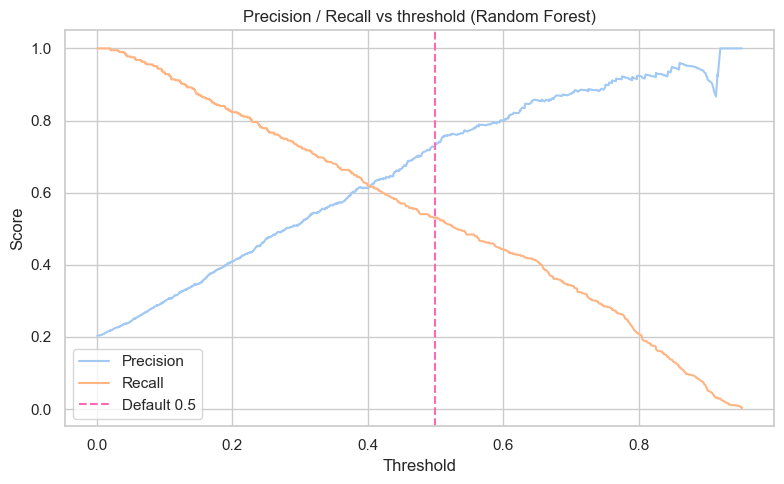

At threshold - Random Forest 0.25
Precision: 0.472
Recall   : 0.779
F1       : 0.588


In [9]:
# Threshold tuning for Random Forest
from sklearn.metrics import precision_recall_curve

best_model, _, X_te_best = models['Random Forest']
y_proba = best_model.predict_proba(X_te_best)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(0.5, color='hotpink', linestyle='--', label='Default 0.5')
plt.xlabel('Threshold'); plt.ylabel('Score');
plt.legend()                                       
plt.title('Precision / Recall vs threshold (Random Forest)')                                        
plt.tight_layout()                               
plt.savefig('../outputs/figures/10_threshold_tuning.png', dpi=120, bbox_inches='tight')               
plt.show()

threshold = 0.25   
y_pred_tuned = (y_proba >= threshold).astype(int)
                                                     
print('At threshold - Random Forest', threshold)                   
print(f'Precision: {precision_score(y_test, y_pred_tuned):.3f}')                            
print(f'Recall   : {recall_score(y_test, y_pred_tuned):.3f}')                 
print(f'F1       : {f1_score(y_test, y_pred_tuned):.3f}')  

In [ ]:
# Save Random Forest for later run
joblib.dump(rf, '../outputs/models/rf_churn.joblib')
print('Saved Random Forest model.')

In [18]:
def predict_churn(model, X_new, threshold=0.25):
    proba = model.predict_proba(X_new)[:, 1]
    return pd.DataFrame({'churn probability': proba,
                        'predicted churn': (proba >= threshold).astype(int),
                        'risk band': pd.cut(proba, bins=[0, 0.25, 0.5, 0.75, 1], labels=['Low','Medium','High','Very High'],),})
scores = predict_churn(rf, X_test, threshold=0.25)
print(scores.head())
print('\nRisk Band Distribution:')
print(scores['risk band'].value_counts().sort_index())
    

   churn probability  predicted churn risk band
0           0.054246                0       Low
1           0.021034                0       Low
2           0.063279                0       Low
3           0.040852                0       Low
4           0.128999                0       Low

Risk Band Distribution:
risk band
Low          1329
Medium        377
High          164
Very High     130
Name: count, dtype: int64


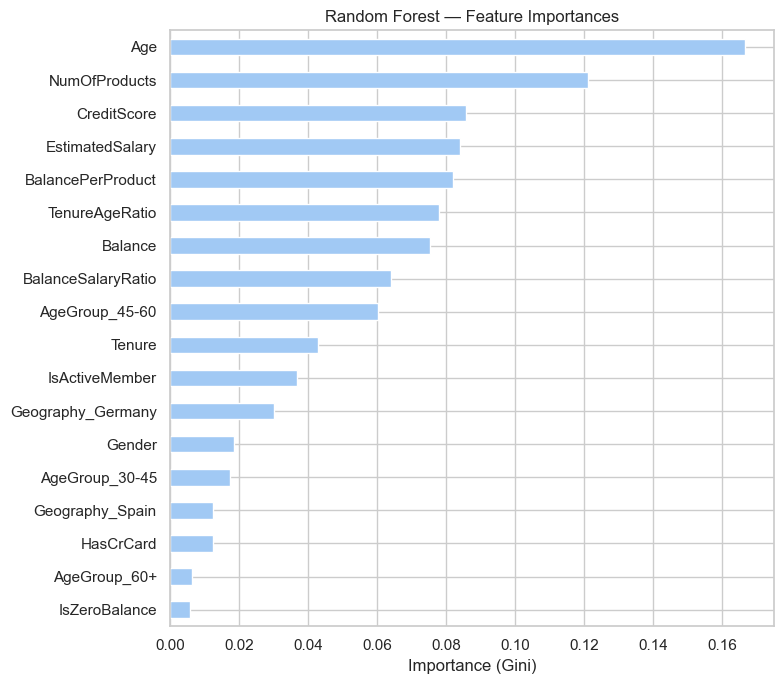


Top 10:
Age                   0.167
NumOfProducts         0.121
CreditScore           0.086
EstimatedSalary       0.084
BalancePerProduct     0.082
TenureAgeRatio        0.078
Balance               0.075
BalanceSalaryRatio    0.064
AgeGroup_45-60        0.060
Tenure                0.043
dtype: float64


In [19]:
# Ranking features

# RF importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns,).sort_values(ascending=True)
                                                     
plt.figure(figsize=(8, 7))
importances.plot(kind='barh')                      
plt.title('Random Forest — Feature Importances')   
plt.xlabel('Importance (Gini)')
plt.tight_layout()                                 
plt.savefig('../outputs/figures/12_rf_feature_importance.png', dpi=120, bbox_inches='tight')          
plt.show()                                       
                                                     
print('\nTop 10:')                               
print(importances.sort_values(ascending=False).head(10).round(3))

In [21]:
# SHAP values
import shap
                                                     
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
                                                                          
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
                                                     
print('SHAP shape:', shap_values.shape)  

SHAP shape: (2000, 18)


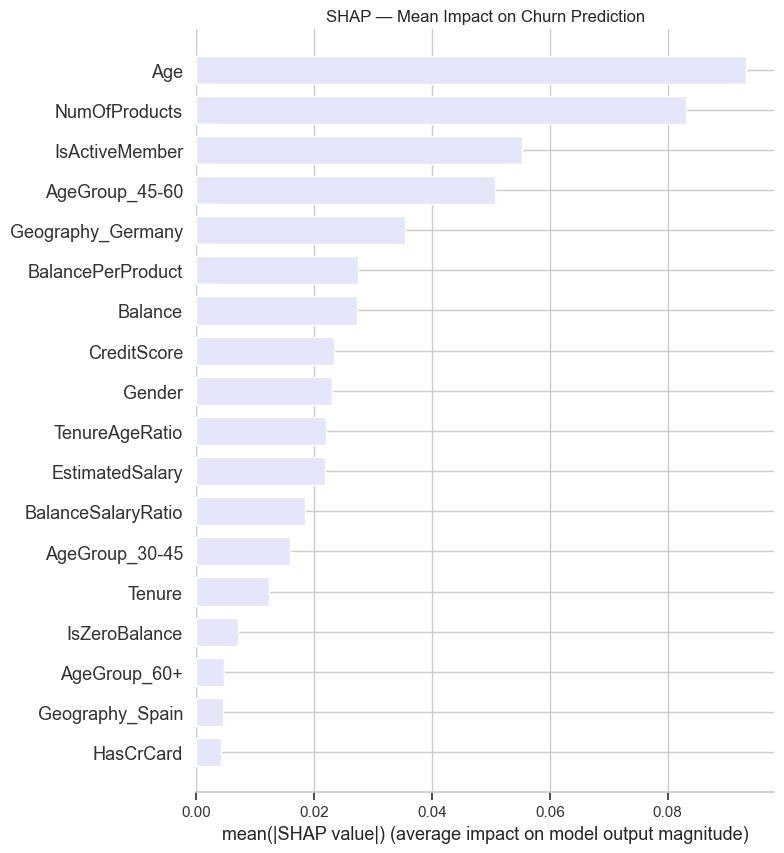

In [27]:
# Plot SHAP Bar
shap.summary_plot(shap_values, X_test,plot_type='bar', show=False, color='lavender')                                                  
plt.title('SHAP — Mean Impact on Churn Prediction')
plt.tight_layout()                                 
plt.savefig('../outputs/figures/13_shap_bar.png', dpi=120, bbox_inches='tight')                      
plt.show()

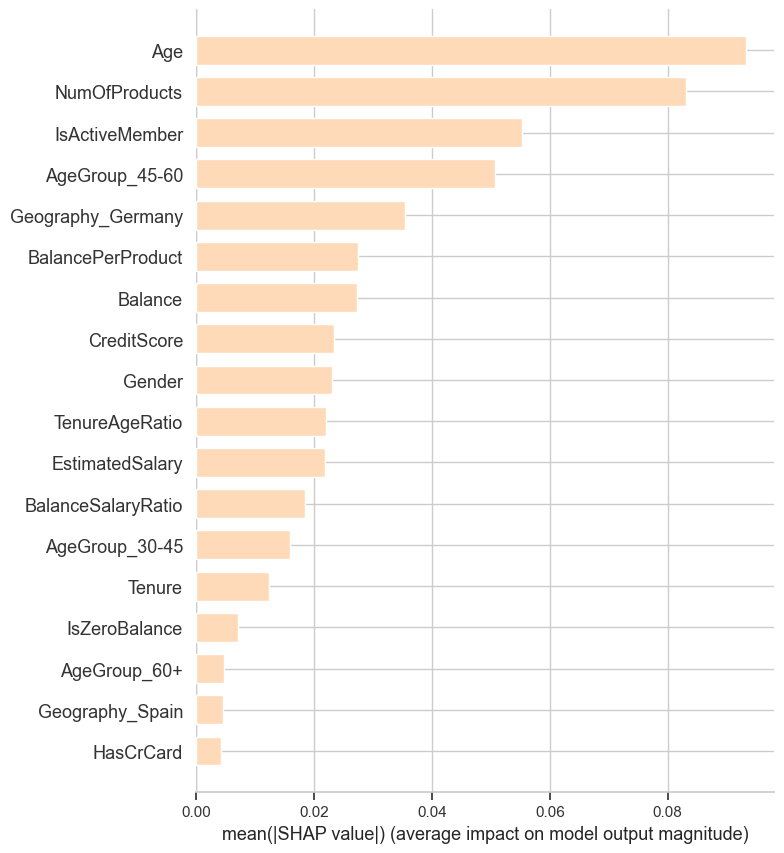

In [29]:
# Plot SHAP Beeswarm
shap.summary_plot(shap_values, X_test,plot_type='bar', show=False, color='#FFDAB9')                                                  
plt.tight_layout()                                 
plt.savefig('../outputs/figures/13_shap_beeswarm.png', dpi=120, bbox_inches='tight')                      
plt.show()

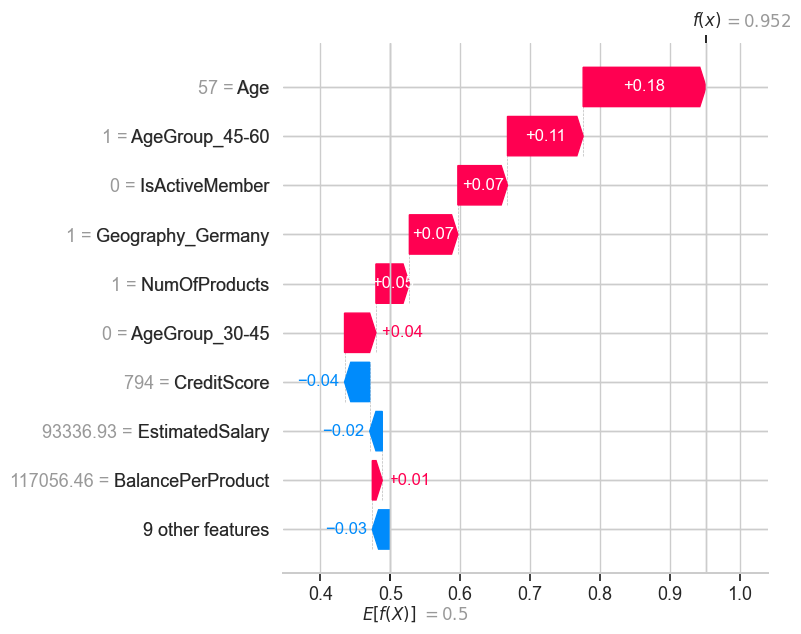

In [24]:
# Waterfall Plots
top_risk_idx = np.argmax(rf.predict_proba(X_test)[:, 1])          
   
shap.plots.waterfall(shap.Explanation(values=shap_values[top_risk_idx],
                                      base_values=explainer.expected_value if np.isscalar(explainer.expected_value)
                                      else explainer.expected_value[1], data=X_test.iloc[top_risk_idx].values, 
                                      feature_names=X_test.columns.tolist(),),show=False)                                                  
plt.tight_layout()
plt.savefig('../outputs/figures/15_shap_waterfall_topcustomer.png', dpi=120, bbox_inches='tight')     
plt.show()

In [30]:
# Save SHAP ranking (later for Tableau use)
shap_importance = pd.DataFrame({'feature': X_test.columns,
                                'mean_abs_shap': np.abs(shap_values).mean(axis=0),}).sort_values('mean_abs_shap', ascending=False)   
                                                     
shap_importance.to_csv('../data/processed/shap_importance.csv', index=False)                          
print(shap_importance.head(10).round(4))

              feature  mean_abs_shap
2                 Age         0.0934
5       NumOfProducts         0.0831
7      IsActiveMember         0.0553
16     AgeGroup_45-60         0.0507
9   Geography_Germany         0.0354
11  BalancePerProduct         0.0274
4             Balance         0.0273
0         CreditScore         0.0233
1              Gender         0.0230
13     TenureAgeRatio         0.0220
